,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,B0_bge_small,509,2.180747,0.833006,0.520629,0.616896,0.726916,0.700786
1,B1_bge_base,509,2.153242,0.836935,0.554813,0.640472,0.717747,0.711421
2,B2_e5_base,509,2.239686,0.842829,0.550491,0.666012,0.746562,0.724931
3,B3_e5_large,509,2.292731,0.886051,0.601572,0.662083,0.764244,0.753910
4,B4_bge_large,509,2.198428,0.856582,0.570138,0.660118,0.732809,0.729057


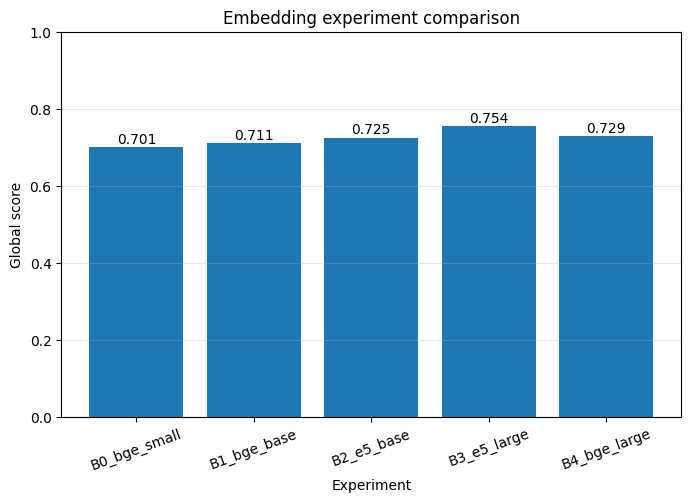

Best embedding experiment: B3_e5_large with global_score = 0.7539


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "B0_bge_small": "Dataset4_B0_bge_small.csv",
    "B1_bge_base": "Dataset4_B1_bge_base.csv",
    "B2_e5_base": "Dataset4_B2_e5_base.csv",
    "B3_e5_large": "Dataset4_B3_e5_large.csv", 
    "B4_bge_large": "Dataset4_B4_bge_large.csv",

}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)

,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,C0_fixed_256,509,2.159136,0.870334,0.564637,0.618861,0.719712,0.721244
1,C1_fixed_512,509,2.290766,0.886051,0.601572,0.662083,0.763589,0.753746
2,C2_fixed_800,509,2.339882,0.888016,0.615324,0.697446,0.779961,0.768350
3,C3_fixed_1024,509,2.345776,0.897839,0.638900,0.726916,0.781925,0.782888
4,C4_paragraph_512,509,2.387033,0.870334,0.558350,0.677800,0.795678,0.750766
5,C5_paragraph_800,509,2.332024,0.872299,0.562279,0.679764,0.777341,0.748048
6,C6_paragraph_1024,509,2.345776,0.872299,0.565815,0.687623,0.781925,0.751473


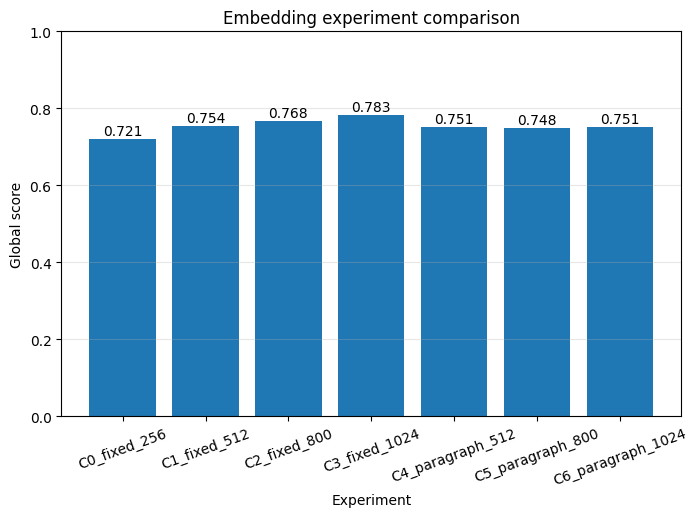

Best embedding experiment: C3_fixed_1024 with global_score = 0.7829


In [2]:
# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "C0_fixed_256": "Dataset4_C0_fixed_256.csv",
    "C1_fixed_512": "Dataset4_C1_fixed_512.csv",
    "C2_fixed_800": "Dataset4_C2_fixed_800.csv",
    "C3_fixed_1024": "Dataset4_C3_fixed_1024.csv",
    "C4_paragraph_512": "Dataset4_C4_paragraph_512.csv",
    "C5_paragraph_800": "Dataset4_C5_paragraph_800.csv",
    "C6_paragraph_1024": "Dataset4_C6_paragraph_1024.csv",
}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)

,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,D0_retrieve_k_10,509,2.349705,0.897839,0.6389,0.726916,0.783235,0.783215
1,D1_retrieve_k_25,509,2.375246,0.897839,0.6389,0.726916,0.791749,0.785344
2,D2_retrieve_k_50,509,2.355599,0.897839,0.6389,0.726916,0.785200,0.783707


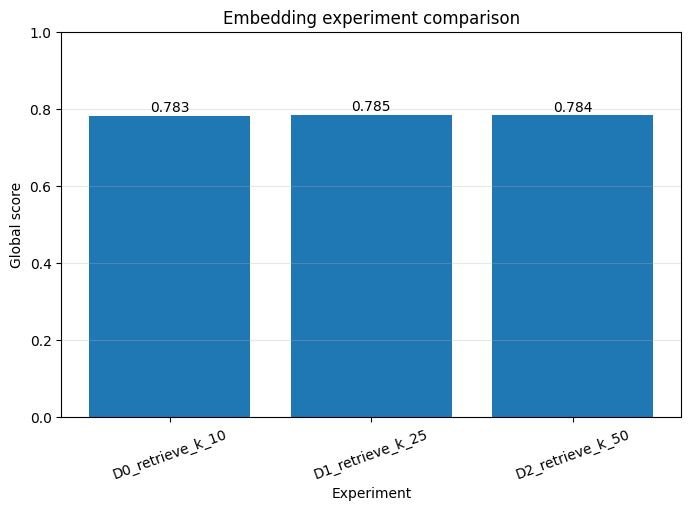

Best embedding experiment: D1_retrieve_k_25 with global_score = 0.7853


In [3]:
# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "D0_retrieve_k_10": "Dataset4_D0_retrieve_k_10.csv",
    "D1_retrieve_k_25": "Dataset4_D1_retrieve_k_25.csv",
    "D2_retrieve_k_50": "Dataset4_D2_retrieve_k_50.csv",
}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)

,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,E0_final_k_3,509,2.290766,0.854617,0.676490,0.726916,0.763589,0.770694
1,E1_final_k_5,509,2.335953,0.897839,0.638900,0.726916,0.778651,0.782069
2,E2_final_k_8,509,2.381139,0.925344,0.608792,0.726916,0.793713,0.789440
3,E3_final_k_12,509,2.471513,0.939096,0.568599,0.726916,0.823838,0.793746
4,E4_final_k_18,509,2.424361,0.956778,0.515062,0.726916,0.808120,0.785298


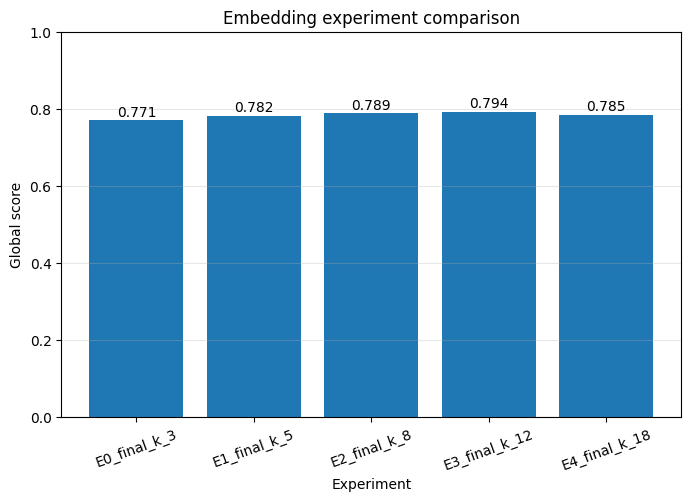

Best embedding experiment: E3_final_k_12 with global_score = 0.7937


In [4]:
# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "E0_final_k_3": "Dataset4_E0_final_k_3.csv",
    "E1_final_k_5": "Dataset4_E1_final_k_5.csv",
    "E2_final_k_8": "Dataset4_E2_final_k_8.csv",
    "E3_final_k_12": "Dataset4_E3_final_k_12.csv",
    "E4_final_k_18": "Dataset4_E4_final_k_18.csv",
}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)

,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,R0_dense_only,509,2.442043,0.939096,0.568599,0.726916,0.814014,0.791290
1,R1_bm25_only_k25,509,2.422397,0.899804,0.471840,0.650295,0.807466,0.741225
2,R2_bm25_only_k50,509,2.424361,0.899804,0.471840,0.650295,0.808120,0.741388
3,R3_hybrid_concat_dense25_bm25_25,509,2.502947,0.946955,0.541912,0.726916,0.834316,0.793779
4,R4_hybrid_rrf_dense25_bm25_25,509,2.502947,0.944990,0.558775,0.728880,0.834316,0.796857
5,R5_hybrid_rrf_dense25_bm25_50,509,2.483301,0.946955,0.567944,0.726916,0.827767,0.797348


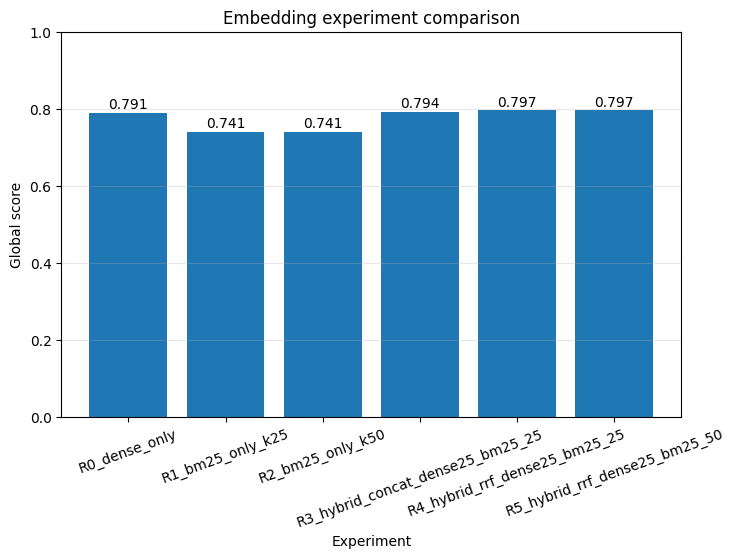

Best embedding experiment: R5_hybrid_rrf_dense25_bm25_50 with global_score = 0.7973


In [5]:
# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "R0_dense_only": "Dataset4_R0_dense_only.csv",
    "R1_bm25_only_k25": "Dataset4_R1_bm25_only_k25.csv",
    "R2_bm25_only_k50": "Dataset4_R2_bm25_only_k50.csv",
    "R3_hybrid_concat_dense25_bm25_25": "Dataset4_R3_hybrid_concat_dense25_bm25_25.csv",
    "R4_hybrid_rrf_dense25_bm25_25": "Dataset4_R4_hybrid_rrf_dense25_bm25_25.csv",
    "R5_hybrid_rrf_dense25_bm25_50": "Dataset4_R5_hybrid_rrf_dense25_bm25_50.csv",
}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)

,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,G0_best_retriever,604,2.662252,0.791391,0.206236,0.574503,0.887417,0.654989
1,G1_graph_seq_only,604,2.677152,0.806291,0.209587,0.589404,0.892384,0.665096
2,G2_graph_domain_concept,604,2.670530,0.789735,0.203418,0.569536,0.890177,0.653542
3,G3_domain_concept_and_seq_min2_hop1,604,2.677152,0.793046,0.204246,0.571192,0.892384,0.655750
4,G4_domain_concept_and_seq_min2_hop2,604,2.634106,0.786424,0.202121,0.562914,0.878035,0.647764
5,G5_graph_hybrid_edges_similarity_hop1_optional,604,2.658940,0.788079,0.204876,0.576159,0.886313,0.653613


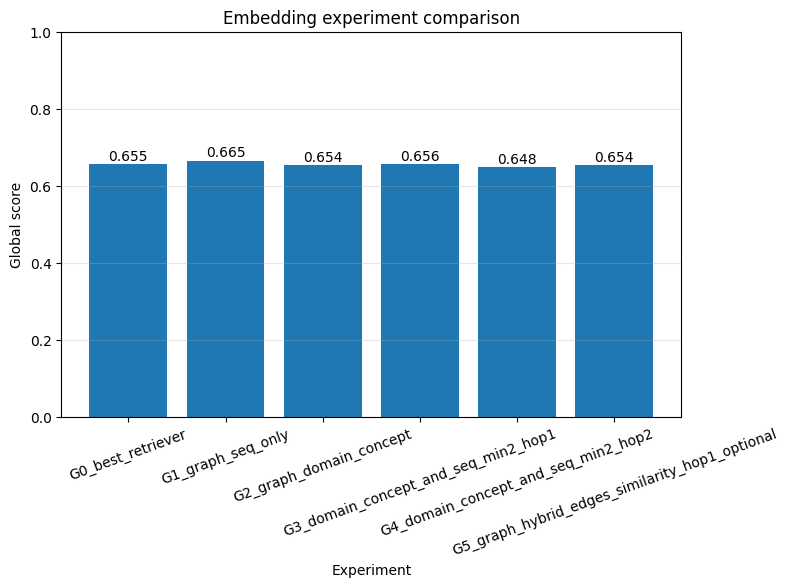

Best embedding experiment: G1_graph_seq_only with global_score = 0.6651


In [6]:
# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "G0_best_retriever": "Dataset5_G0_best_retriever_no_graph.csv",
    "G1_graph_seq_only": "Dataset5_G1_graph_sequential_only_hop1.csv",
    "G2_graph_domain_concept": "Dataset5_G2_graph_domain_concept_only_min2_hop1.csv",
    "G3_domain_concept_and_seq_min2_hop1": "Dataset5_G3_graph_domain_concept_plus_sequential_min2_hop1.csv",
    "G4_domain_concept_and_seq_min2_hop2": "Dataset5_G4_graph_domain_concept_plus_sequential_min2_hop2.csv",
    "G5_graph_hybrid_edges_similarity_hop1_optional": "Dataset5_G5_graph_hybrid_edges_similarity_hop1_optional.csv",
}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)

,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,I1_best_retriever,509,2.483301,0.946955,0.567944,0.726916,0.827767,0.797348
1,I2_lexical_rerank,509,2.300589,0.848723,0.319745,0.377210,0.766863,0.628160
2,I3_cross_encoder_rerank,509,2.493124,0.954813,0.574656,0.711198,0.831041,0.799116


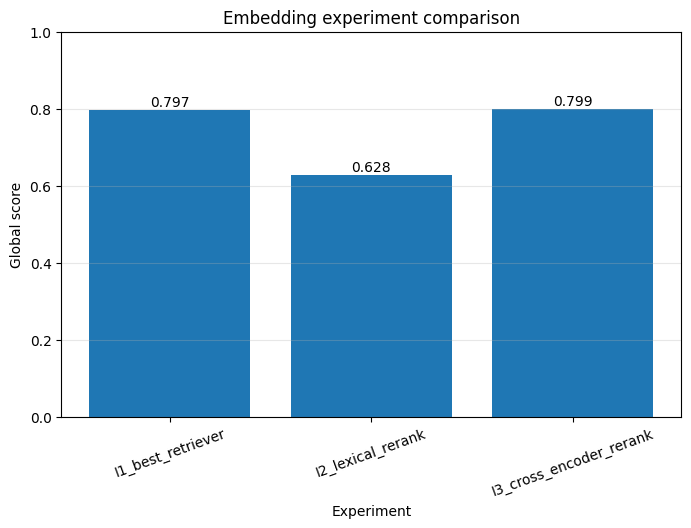

Best embedding experiment: I3_cross_encoder_rerank with global_score = 0.7991


In [7]:
# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "I1_best_retriever": "Dataset4_R5_hybrid_rrf_dense25_bm25_50.csv",
    "I2_lexical_rerank": "Dataset4_I1_best_retriever_no_graph_lexical_rerank.csv",
    "I3_cross_encoder_rerank": "Dataset4_I2_best_retriever_no_graph_cross_encoder_rerank.csv",
}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)

,experiment,n_questions,llm_score,paper_recall,chunk_precision,top_chunk_accuracy,llm_score_norm,global_score
0,I1_best_retriever,509,2.483301,0.946955,0.567944,0.726916,0.827767,0.797348
1,I2_graph_lexical_rerank,509,2.328094,0.854617,0.322528,0.377210,0.776031,0.633071
2,I3_graph_cross_encoder_rerank,509,2.487230,0.954813,0.574656,0.711198,0.829077,0.798625


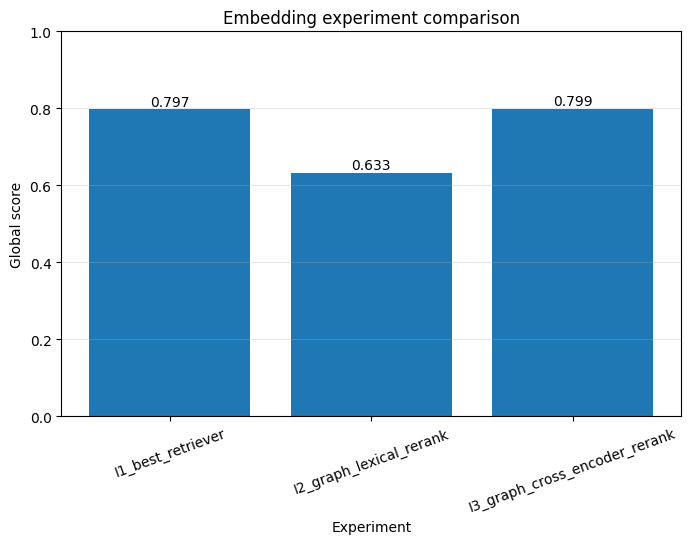

Best embedding experiment: I3_graph_cross_encoder_rerank with global_score = 0.7986


In [8]:
# =========================
# Files / experiments
# =========================

EXPERIMENTS = {
    "I1_best_retriever": "Dataset4_R5_hybrid_rrf_dense25_bm25_50.csv",
    "I2_graph_lexical_rerank": "Dataset4_I1_best_graph_lexical_rerank.csv",
    "I3_graph_cross_encoder_rerank": "Dataset4_I2_best_graph_cross_encoder_rerank.csv",
}

MAIN_METRICS = [
    "llm_score",
    "paper_recall",
    "chunk_precision",
    "top_chunk_accuracy",
]

# =========================
# Read + summarize
# =========================

rows = []

for exp_name, csv_file in EXPERIMENTS.items():
    df = pd.read_csv(csv_file)

    row = {
        "experiment": exp_name,
        "n_questions": len(df),
        "llm_score": df["llm_score"].mean(),
        "paper_recall": df["paper_recall"].mean(),
        "chunk_precision": df["chunk_precision"].mean(),
        "top_chunk_accuracy": df["top_chunk_accuracy"].mean(),
    }

    # Normalize LLM score because it is between 0 and 3
    row["llm_score_norm"] = row["llm_score"] / 3

    # Global score on 0-1 scale
    row["global_score"] = (
        0.25 * row["llm_score_norm"]
        + 0.35 * row["paper_recall"]
        + 0.20 * row["chunk_precision"]
        + 0.20 * row["top_chunk_accuracy"]
    )

    rows.append(row)

summary_df = pd.DataFrame(rows)

display(summary_df)

# =========================
# Plot global score
# =========================

plt.figure(figsize=(8, 5))
plt.bar(summary_df["experiment"], summary_df["global_score"])

plt.title("Embedding experiment comparison")
plt.xlabel("Experiment")
plt.ylabel("Global score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(summary_df["global_score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha="center")

plt.show()

# =========================
# Print best experiment
# =========================

best_idx = summary_df["global_score"].idxmax()
best = summary_df.loc[best_idx]

print(
    f"Best embedding experiment: {best['experiment']} "
    f"with global_score = {best['global_score']:.4f}"
)